In [1]:
print("The objective of this project it's to predict the higher value and the close value for each day")

The objective of this project it's to predict the higher value and the close value for each day


In [2]:
import pandas as pd

df = pd.read_csv("../../datasets/apple_stock.csv")
df

,Unnamed: 0,Adj Close,Close,High,Low,Open,Volume
0,1980-12-12,0.098834,0.128348,0.128906,0.128348,0.128348,469033600
1,1980-12-15,0.093678,0.121652,0.122210,0.121652,0.122210,175884800
2,1980-12-16,0.086802,0.112723,0.113281,0.112723,0.113281,105728000
3,1980-12-17,0.088951,0.115513,0.116071,0.115513,0.115513,86441600
4,1980-12-18,0.091530,0.118862,0.119420,0.118862,0.118862,73449600
...,...,...,...,...,...,...,...
11102,2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300
11103,2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500
11104,2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700
11105,2025-01-02,243.850006,243.850006,249.100006,241.820007,248.929993,55558000


In [3]:
print("For market shares actions, we need to see the past for analyze the future, so we need to use the t-1 for t, so remove it the first target and last sample")

For market shares actions, we need to see the past for analyze the future, so we need to use the t-1 for t, so remove it the first target and last sample


## EDA FOR CLOSE VALUE

In [4]:
df.head()

,Unnamed: 0,Adj Close,Close,High,Low,Open,Volume
0,1980-12-12,0.098834,0.128348,0.128906,0.128348,0.128348,469033600
1,1980-12-15,0.093678,0.121652,0.122210,0.121652,0.122210,175884800
2,1980-12-16,0.086802,0.112723,0.113281,0.112723,0.113281,105728000
3,1980-12-17,0.088951,0.115513,0.116071,0.115513,0.115513,86441600
4,1980-12-18,0.091530,0.118862,0.119420,0.118862,0.118862,73449600


In [5]:
df['date'] = pd.to_datetime(df['Unnamed: 0'])


In [6]:
df

,Unnamed: 0,Adj Close,Close,High,Low,Open,Volume,date
0,1980-12-12,0.098834,0.128348,0.128906,0.128348,0.128348,469033600,1980-12-12
1,1980-12-15,0.093678,0.121652,0.122210,0.121652,0.122210,175884800,1980-12-15
2,1980-12-16,0.086802,0.112723,0.113281,0.112723,0.113281,105728000,1980-12-16
3,1980-12-17,0.088951,0.115513,0.116071,0.115513,0.115513,86441600,1980-12-17
4,1980-12-18,0.091530,0.118862,0.119420,0.118862,0.118862,73449600,1980-12-18
...,...,...,...,...,...,...,...,...
11102,2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300,2024-12-27
11103,2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500,2024-12-30
11104,2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700,2024-12-31
11105,2025-01-02,243.850006,243.850006,249.100006,241.820007,248.929993,55558000,2025-01-02


In [7]:
df['Close'] == df['Low']

0         True
1         True
2         True
3         True
4         True
         ...  
11102    False
11103    False
11104    False
11105    False
11106    False
Length: 11107, dtype: bool

In [8]:
df['year'] = df['date'].dt.year
df['weekday'] = df['date'].dt.weekday
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df

,Unnamed: 0,Adj Close,Close,High,Low,Open,Volume,date,year,weekday,day,month
0,1980-12-12,0.098834,0.128348,0.128906,0.128348,0.128348,469033600,1980-12-12,1980,4,12,12
1,1980-12-15,0.093678,0.121652,0.122210,0.121652,0.122210,175884800,1980-12-15,1980,0,15,12
2,1980-12-16,0.086802,0.112723,0.113281,0.112723,0.113281,105728000,1980-12-16,1980,1,16,12
3,1980-12-17,0.088951,0.115513,0.116071,0.115513,0.115513,86441600,1980-12-17,1980,2,17,12
4,1980-12-18,0.091530,0.118862,0.119420,0.118862,0.118862,73449600,1980-12-18,1980,3,18,12
...,...,...,...,...,...,...,...,...,...,...,...,...
11102,2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300,2024-12-27,2024,4,27,12
11103,2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500,2024-12-30,2024,0,30,12
11104,2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700,2024-12-31,2024,1,31,12
11105,2025-01-02,243.850006,243.850006,249.100006,241.820007,248.929993,55558000,2025-01-02,2025,3,2,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11107 entries, 0 to 11106
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  11107 non-null  object        
 1   Adj Close   11107 non-null  float64       
 2   Close       11107 non-null  float64       
 3   High        11107 non-null  float64       
 4   Low         11107 non-null  float64       
 5   Open        11107 non-null  float64       
 6   Volume      11107 non-null  int64         
 7   date        11107 non-null  datetime64[ns]
 8   year        11107 non-null  int32         
 9   weekday     11107 non-null  int32         
 10  day         11107 non-null  int32         
 11  month       11107 non-null  int32         
dtypes: datetime64[ns](1), float64(5), int32(4), int64(1), object(1)
memory usage: 867.9+ KB


In [10]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume,date,year,weekday,day,month
count,11107.000000,11107.000000,11107.000000,11107.000000,11107.000000,1.110700e+04,11107,11107.000000,11107.000000,11107.000000,11107.000000
mean,23.522229,24.357607,24.598169,24.092608,24.339076,3.154341e+08,2002-12-14 15:31:54.576393216,2002.451787,2.018277,15.740164,6.543531
min,0.037815,0.049107,0.049665,0.049107,0.049665,0.000000e+00,1980-12-12 00:00:00,1980.000000,0.000000,1.000000,1.000000
25%,0.243402,0.300290,0.306362,0.292411,0.300090,1.111164e+08,1991-12-05 12:00:00,1991.000000,1.000000,8.000000,4.000000
50%,0.446682,0.542411,0.553393,0.534598,0.542679,2.036944e+08,2002-12-10 00:00:00,2002.000000,2.000000,16.000000,7.000000
75%,18.260086,21.397143,21.569285,21.115715,21.367679,3.960418e+08,2013-12-19 12:00:00,2013.000000,3.000000,23.000000,10.000000
max,259.019989,259.019989,260.100006,257.630005,258.190002,7.421641e+09,2025-01-03 00:00:00,2025.000000,4.000000,31.000000,12.000000
std,49.767881,50.217498,50.691902,49.682631,50.166818,3.348735e+08,NaN,12.720212,1.400564,8.748194,3.434627


In [11]:
df = df[df['year'] >= 2000]
df

,Unnamed: 0,Adj Close,Close,High,Low,Open,Volume,date,year,weekday,day,month
4816,2000-01-03,0.843077,0.999442,1.004464,0.907924,0.936384,535796800,2000-01-03,2000,0,3,1
4817,2000-01-04,0.771997,0.915179,0.987723,0.903460,0.966518,512377600,2000-01-04,2000,1,4,1
4818,2000-01-05,0.783293,0.928571,0.987165,0.919643,0.926339,778321600,2000-01-05,2000,2,5,1
4819,2000-01-06,0.715509,0.848214,0.955357,0.848214,0.947545,767972800,2000-01-06,2000,3,6,1
4820,2000-01-07,0.749401,0.888393,0.901786,0.852679,0.861607,460734400,2000-01-07,2000,4,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...
11102,2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300,2024-12-27,2024,4,27,12
11103,2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500,2024-12-30,2024,0,30,12
11104,2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700,2024-12-31,2024,1,31,12
11105,2025-01-02,243.850006,243.850006,249.100006,241.820007,248.929993,55558000,2025-01-02,2025,3,2,1


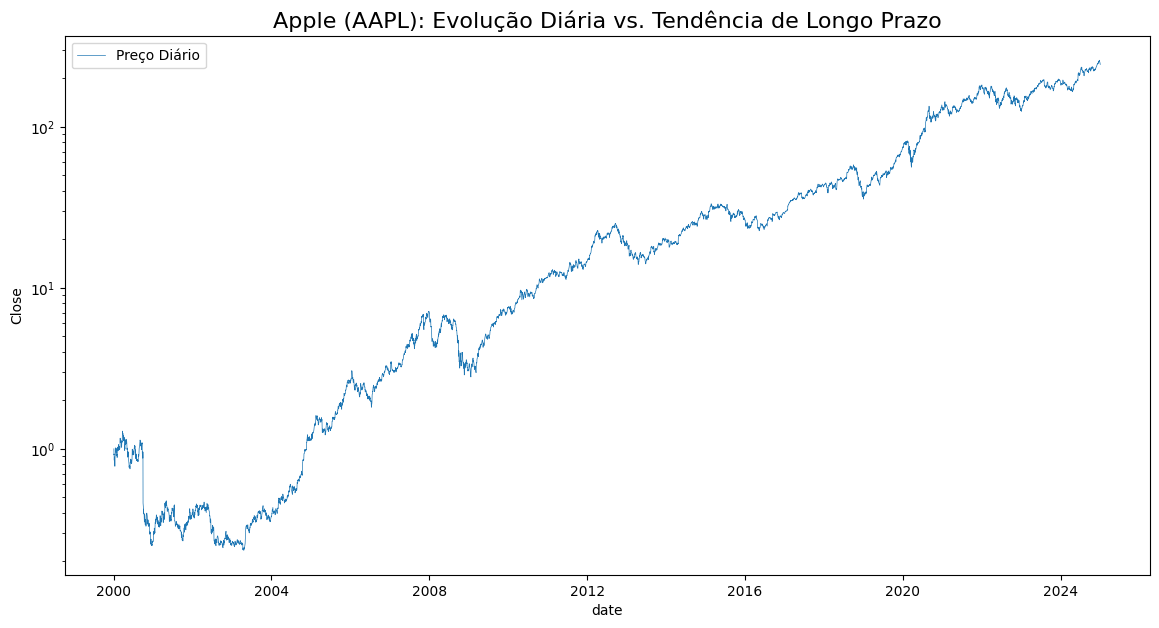

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.lineplot(data=df, x='date', y='Close', label='Preço Diário', linewidth=0.5)

plt.title('Apple (AAPL): Evolução Diária vs. Tendência de Longo Prazo', fontsize=16)
plt.yscale('log') 
plt.legend()
plt.show()

In [13]:
n_lags = 7 


df = df.copy()
for lag in range(1, n_lags + 1):
    df[f'close_lag_{lag}'] = df['Close'].shift(lag)

df

,Unnamed: 0,Adj Close,Close,High,Low,Open,Volume,date,year,weekday,day,month,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5,close_lag_6,close_lag_7
4816,2000-01-03,0.843077,0.999442,1.004464,0.907924,0.936384,535796800,2000-01-03,2000,0,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4817,2000-01-04,0.771997,0.915179,0.987723,0.903460,0.966518,512377600,2000-01-04,2000,1,4,1,0.999442,NaN,NaN,NaN,NaN,NaN,NaN
4818,2000-01-05,0.783293,0.928571,0.987165,0.919643,0.926339,778321600,2000-01-05,2000,2,5,1,0.915179,0.999442,NaN,NaN,NaN,NaN,NaN
4819,2000-01-06,0.715509,0.848214,0.955357,0.848214,0.947545,767972800,2000-01-06,2000,3,6,1,0.928571,0.915179,0.999442,NaN,NaN,NaN,NaN
4820,2000-01-07,0.749401,0.888393,0.901786,0.852679,0.861607,460734400,2000-01-07,2000,4,7,1,0.848214,0.928571,0.915179,0.999442,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11102,2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300,2024-12-27,2024,4,27,12,259.019989,258.200012,255.270004,254.490005,249.789993,248.050003,253.479996
11103,2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500,2024-12-30,2024,0,30,12,255.589996,259.019989,258.200012,255.270004,254.490005,249.789993,248.050003
11104,2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700,2024-12-31,2024,1,31,12,252.199997,255.589996,259.019989,258.200012,255.270004,254.490005,249.789993
11105,2025-01-02,243.850006,243.850006,249.100006,241.820007,248.929993,55558000,2025-01-02,2025,3,2,1,250.419998,252.199997,255.589996,259.019989,258.200012,255.270004,254.490005


In [14]:
df.isnull().sum()

Unnamed: 0     0
Adj Close      0
Close          0
High           0
Low            0
Open           0
Volume         0
date           0
year           0
weekday        0
day            0
month          0
close_lag_1    1
close_lag_2    2
close_lag_3    3
close_lag_4    4
close_lag_5    5
close_lag_6    6
close_lag_7    7
dtype: int64

In [15]:
df.dropna(inplace = True)
df.isnull().sum()

Unnamed: 0     0
Adj Close      0
Close          0
High           0
Low            0
Open           0
Volume         0
date           0
year           0
weekday        0
day            0
month          0
close_lag_1    0
close_lag_2    0
close_lag_3    0
close_lag_4    0
close_lag_5    0
close_lag_6    0
close_lag_7    0
dtype: int64

In [16]:
df['target_close'] = df['Close'].shift(-1)
df = df.dropna().reset_index(drop=True)

In [17]:
df

,Unnamed: 0,Adj Close,Close,High,Low,Open,Volume,date,year,weekday,day,month,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5,close_lag_6,close_lag_7,target_close
0,2000-01-12,0.656668,0.778460,0.852679,0.772321,0.848214,976068800,2000-01-12,2000,2,12,1,0.828125,0.872768,0.888393,0.848214,0.928571,0.915179,0.999442,0.863839
1,2000-01-13,0.728689,0.863839,0.881696,0.825893,0.843610,1032684800,2000-01-13,2000,3,13,1,0.778460,0.828125,0.872768,0.888393,0.848214,0.928571,0.915179,0.896763
2,2000-01-14,0.756462,0.896763,0.912946,0.887277,0.892857,390376000,2000-01-14,2000,4,14,1,0.863839,0.778460,0.828125,0.872768,0.888393,0.848214,0.928571,0.928013
3,2000-01-18,0.782823,0.928013,0.946429,0.896763,0.901786,459177600,2000-01-18,2000,1,18,1,0.896763,0.863839,0.778460,0.828125,0.872768,0.888393,0.848214,0.951451
4,2000-01-19,0.802594,0.951451,0.970982,0.922991,0.943080,597643200,2000-01-19,2000,2,19,1,0.928013,0.896763,0.863839,0.778460,0.828125,0.872768,0.888393,1.013393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6278,2024-12-26,259.019989,259.019989,260.100006,257.630005,258.190002,27237100,2024-12-26,2024,3,26,12,258.200012,255.270004,254.490005,249.789993,248.050003,253.479996,251.039993,255.589996
6279,2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300,2024-12-27,2024,4,27,12,259.019989,258.200012,255.270004,254.490005,249.789993,248.050003,253.479996,252.199997
6280,2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500,2024-12-30,2024,0,30,12,255.589996,259.019989,258.200012,255.270004,254.490005,249.789993,248.050003,250.419998
6281,2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700,2024-12-31,2024,1,31,12,252.199997,255.589996,259.019989,258.200012,255.270004,254.490005,249.789993,243.850006


In [18]:
df.drop(columns = ['Unnamed: 0', 'date'], inplace = True)
df

,Adj Close,Close,High,Low,Open,Volume,year,weekday,day,month,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5,close_lag_6,close_lag_7,target_close
0,0.656668,0.778460,0.852679,0.772321,0.848214,976068800,2000,2,12,1,0.828125,0.872768,0.888393,0.848214,0.928571,0.915179,0.999442,0.863839
1,0.728689,0.863839,0.881696,0.825893,0.843610,1032684800,2000,3,13,1,0.778460,0.828125,0.872768,0.888393,0.848214,0.928571,0.915179,0.896763
2,0.756462,0.896763,0.912946,0.887277,0.892857,390376000,2000,4,14,1,0.863839,0.778460,0.828125,0.872768,0.888393,0.848214,0.928571,0.928013
3,0.782823,0.928013,0.946429,0.896763,0.901786,459177600,2000,1,18,1,0.896763,0.863839,0.778460,0.828125,0.872768,0.888393,0.848214,0.951451
4,0.802594,0.951451,0.970982,0.922991,0.943080,597643200,2000,2,19,1,0.928013,0.896763,0.863839,0.778460,0.828125,0.872768,0.888393,1.013393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6278,259.019989,259.019989,260.100006,257.630005,258.190002,27237100,2024,3,26,12,258.200012,255.270004,254.490005,249.789993,248.050003,253.479996,251.039993,255.589996
6279,255.589996,255.589996,258.700012,253.059998,257.829987,42355300,2024,4,27,12,259.019989,258.200012,255.270004,254.490005,249.789993,248.050003,253.479996,252.199997
6280,252.199997,252.199997,253.500000,250.750000,252.229996,35557500,2024,0,30,12,255.589996,259.019989,258.200012,255.270004,254.490005,249.789993,248.050003,250.419998
6281,250.419998,250.419998,253.279999,249.429993,252.440002,39480700,2024,1,31,12,252.199997,255.589996,259.019989,258.200012,255.270004,254.490005,249.789993,243.850006


In [19]:
X = df.drop('target_close', axis = 1)
X

,Adj Close,Close,High,Low,Open,Volume,year,weekday,day,month,close_lag_1,close_lag_2,close_lag_3,close_lag_4,close_lag_5,close_lag_6,close_lag_7
0,0.656668,0.778460,0.852679,0.772321,0.848214,976068800,2000,2,12,1,0.828125,0.872768,0.888393,0.848214,0.928571,0.915179,0.999442
1,0.728689,0.863839,0.881696,0.825893,0.843610,1032684800,2000,3,13,1,0.778460,0.828125,0.872768,0.888393,0.848214,0.928571,0.915179
2,0.756462,0.896763,0.912946,0.887277,0.892857,390376000,2000,4,14,1,0.863839,0.778460,0.828125,0.872768,0.888393,0.848214,0.928571
3,0.782823,0.928013,0.946429,0.896763,0.901786,459177600,2000,1,18,1,0.896763,0.863839,0.778460,0.828125,0.872768,0.888393,0.848214
4,0.802594,0.951451,0.970982,0.922991,0.943080,597643200,2000,2,19,1,0.928013,0.896763,0.863839,0.778460,0.828125,0.872768,0.888393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6278,259.019989,259.019989,260.100006,257.630005,258.190002,27237100,2024,3,26,12,258.200012,255.270004,254.490005,249.789993,248.050003,253.479996,251.039993
6279,255.589996,255.589996,258.700012,253.059998,257.829987,42355300,2024,4,27,12,259.019989,258.200012,255.270004,254.490005,249.789993,248.050003,253.479996
6280,252.199997,252.199997,253.500000,250.750000,252.229996,35557500,2024,0,30,12,255.589996,259.019989,258.200012,255.270004,254.490005,249.789993,248.050003
6281,250.419998,250.419998,253.279999,249.429993,252.440002,39480700,2024,1,31,12,252.199997,255.589996,259.019989,258.200012,255.270004,254.490005,249.789993


In [20]:
y = df[['target_close']]
y

,target_close
0,0.863839
1,0.896763
2,0.928013
3,0.951451
4,1.013393
...,...
6278,255.589996
6279,252.199997
6280,250.419998
6281,243.850006


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(4712, 17) (4712, 1)
(1571, 17) (1571, 1)


--------------------------------------------
MODEL: LinearRegression()
The accuracy in validation set it's: R2: 99.96%, mae:0.146
The accuracy of in test set it's: R2: 99.80%, mae:1.750


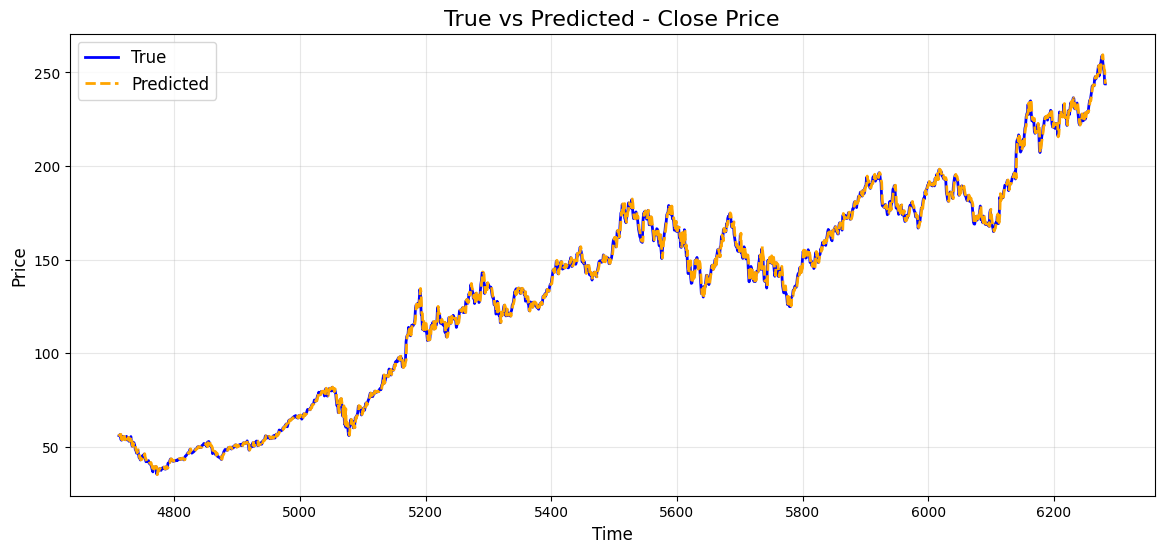

--------------------------------------------
MODEL: DecisionTreeRegressor()
The accuracy in validation set it's: R2: 100.00%, mae:0.000
The accuracy of in test set it's: R2: -196.35%, mae:79.418


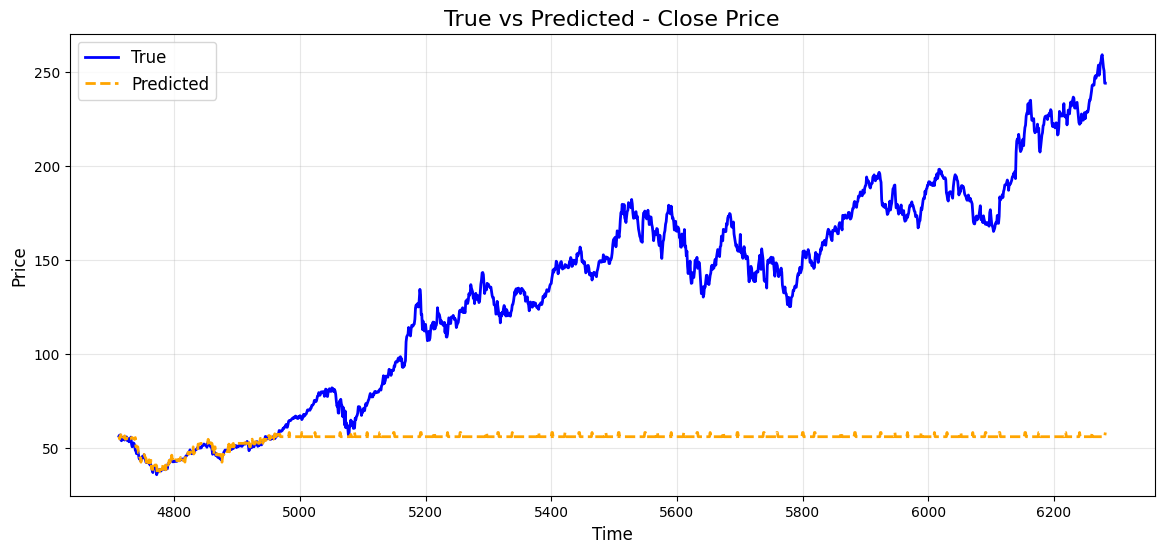

--------------------------------------------
MODEL: KNeighborsRegressor()


c:\Users\tevos\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\tevos\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\tevos\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tevos\AppData\Local\Programs\Python\Python313\Lib\subprocess.py",

The accuracy in validation set it's: R2: 99.87%, mae:0.352
The accuracy of in test set it's: R2: -193.80%, mae:79.093


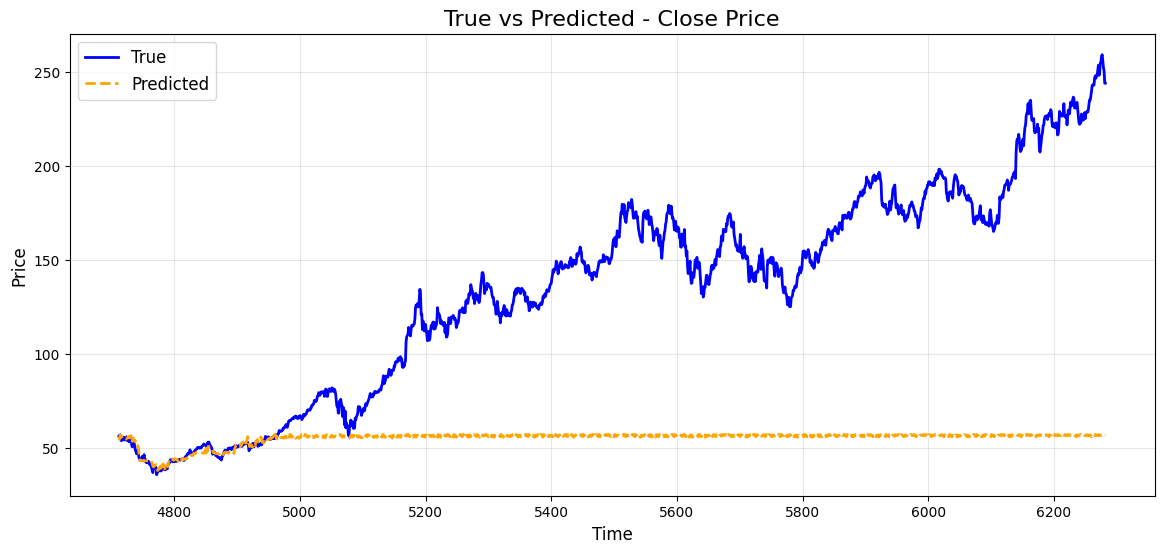

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


models = [LinearRegression(), DecisionTreeRegressor(), KNeighborsRegressor()]

for model in models:
        print('--------------------------------------------')
        print(f"MODEL: {model}")

        pipe = Pipeline(
                steps=[
                ('Scaler', StandardScaler()),
                ("Model", model)
                ]
        )
        # TRAIN THE MODEL
        pipe.fit(X_train, y_train)

        # SEE THE ACCURACY OF THE TRAIN
        y_preds_train = pipe.predict(X_train)
        r2 = r2_score(y_train, y_preds_train)
        mae = mean_absolute_error(y_train, y_preds_train)
        print(F"The accuracy in validation set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")


        # SEE THE ACCURACY OF THE TEST
        y_preds_test = pipe.predict(X_test)
        r2 = r2_score(y_test, y_preds_test)
        mae = mean_absolute_error(y_test, y_preds_test)
        print(F"The accuracy of in test set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")

        plt.figure(figsize=(14,6))
        plt.plot(y_test.index, y_test.values, label='True', color='blue', linewidth=2)
        plt.plot(y_test.index, y_preds_test, label='Predicted', color='orange', linestyle='--', linewidth=2)
        plt.title("True vs Predicted - Close Price", fontsize=16)
        plt.xlabel("Time", fontsize=12)
        plt.ylabel("Price", fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=12)
        plt.show()

        

Model: Polynomial Regression, degree: 2
The accuracy in validation set it's: R2: 99.97%, mae:0.142
The accuracy of in test set it's: R2: 96.69%, mae:6.904


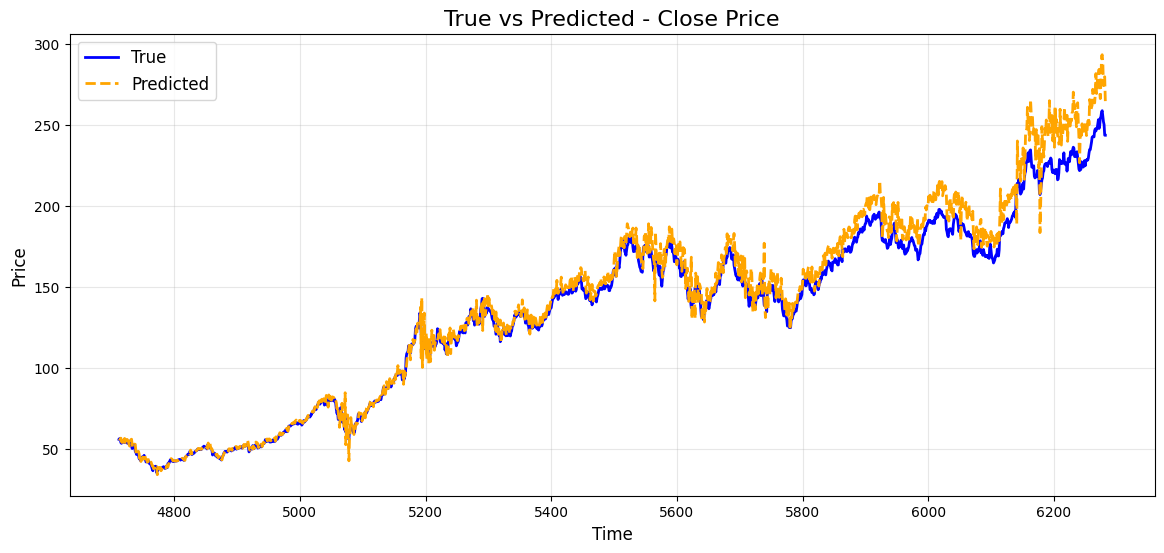

Model: Polynomial Regression, degree: 3
The accuracy in validation set it's: R2: 99.99%, mae:0.104
The accuracy of in test set it's: R2: -20069.35%, mae:367.995


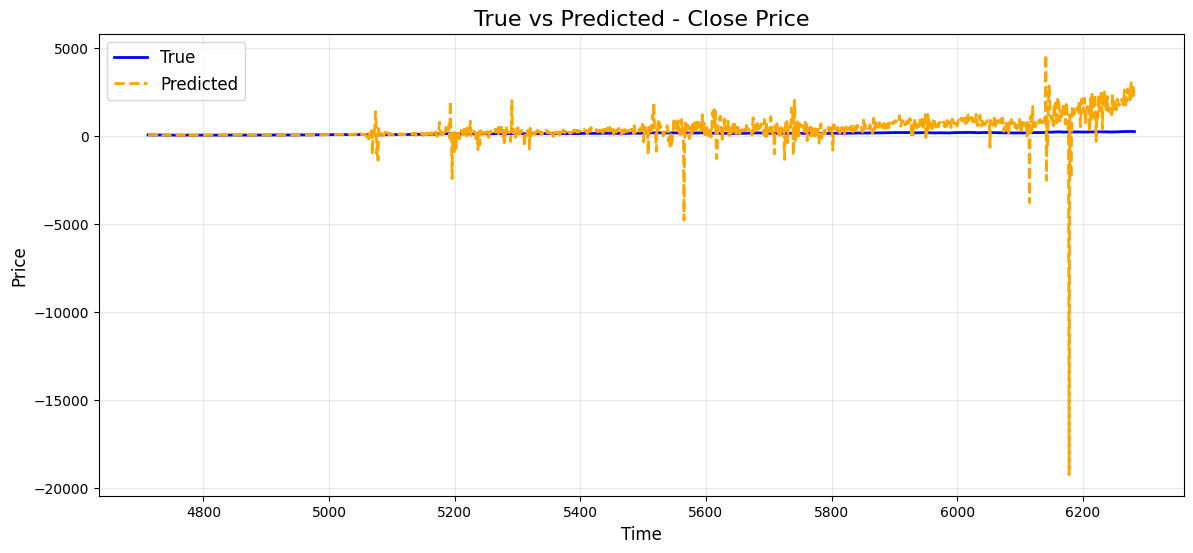

In [23]:
degrees = 4

for degree in range(2, degrees):
    pipe = Pipeline(
    steps=[
        ("Scaler", StandardScaler()),
        ("Polynominal", PolynomialFeatures(degree = degree)),
        ("Model", LinearRegression())
    ])
    pipe.fit(X_train, y_train)

    # SEE THE ACCURACY OF THE TRAIN
    print(f"Model: Polynomial Regression, degree: {degree}")
    y_preds_train = pipe.predict(X_train)
    r2 = r2_score(y_train, y_preds_train)
    mae = mean_absolute_error(y_train, y_preds_train)
    print(F"The accuracy in validation set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")


    # SEE THE ACCURACY OF THE TEST
    y_preds_test = pipe.predict(X_test)
    r2 = r2_score(y_test, y_preds_test)
    mae = mean_absolute_error(y_test, y_preds_test)
    print(F"The accuracy of in test set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")

    plt.figure(figsize=(14,6))
    plt.plot(y_test.index, y_test.values, label='True', color='blue', linewidth=2)
    plt.plot(y_test.index, y_preds_test, label='Predicted', color='orange', linestyle='--', linewidth=2)
    plt.title("True vs Predicted - Close Price", fontsize=16)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.show()
    